# QQ音乐中部分歌手与歌曲数据分析

*2025010563 葛沐昊*

---

In [1]:
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

## 加载数据

- 从爬虫爬取到的原生数据`data`目录中加载数据。

In [2]:
data_dir = "crawler/data"
singers_dir = os.path.join(data_dir, "singers")
songs_dir = os.path.join(data_dir, "songs")

# loading lists
with open(os.path.join(data_dir, "singers_list.json"), "r", encoding="utf-8") as f:
    singers_list = json.load(f)
    
with open(os.path.join(data_dir, "songs_list.json"), "r", encoding="utf-8") as f:
    songs_list = json.load(f)
    
singers = {}
songs = {}

for mid in singers_list:
    singer_file = os.path.join(singers_dir, mid, "info.json")
    if not os.path.exists(singer_file):
        print(f"Missing singer file: {singer_file}")
    else:
        with open(singer_file, "r", encoding="utf-8") as f:
            singers[mid] = json.load(f)
            
for mid in songs_list:
    song_file = os.path.join(songs_dir, mid, "info.json")
    if not os.path.exists(song_file):
        print(f"Missing song file: {song_file}")
    else:
        with open(song_file, "r", encoding="utf-8") as f:
            songs[mid] = json.load(f)
            

print(f"Loaded {len(singers)} singers and {len(songs)} songs.")


Loaded 400 singers and 3848 songs.


- 显示当前数据属性

In [3]:
print("Singer keys:")

for key in list(singers.values())[0].keys():
    print(key)
    
print("=" * 20)
    
print("Song keys:")

for key in list(songs.values())[0].keys():
    print(key)


Singer keys:
name
intro
mid
num_songs
num_albums
num_movies
num_followers
popular_songs
similiar_singers
Song keys:
name
mid
singer
singer_mid
intro
album
language
style
release_date
lyrics
num_comments


## 1. 流派分析

- 根据 `"style"` 属性划分流派
- 结论：
    - **数据集中Pop风格歌曲占比压倒性占据优势**
    - **在相关的评论数上，数量靠前的三者分别为World Music、Folk、Pop**

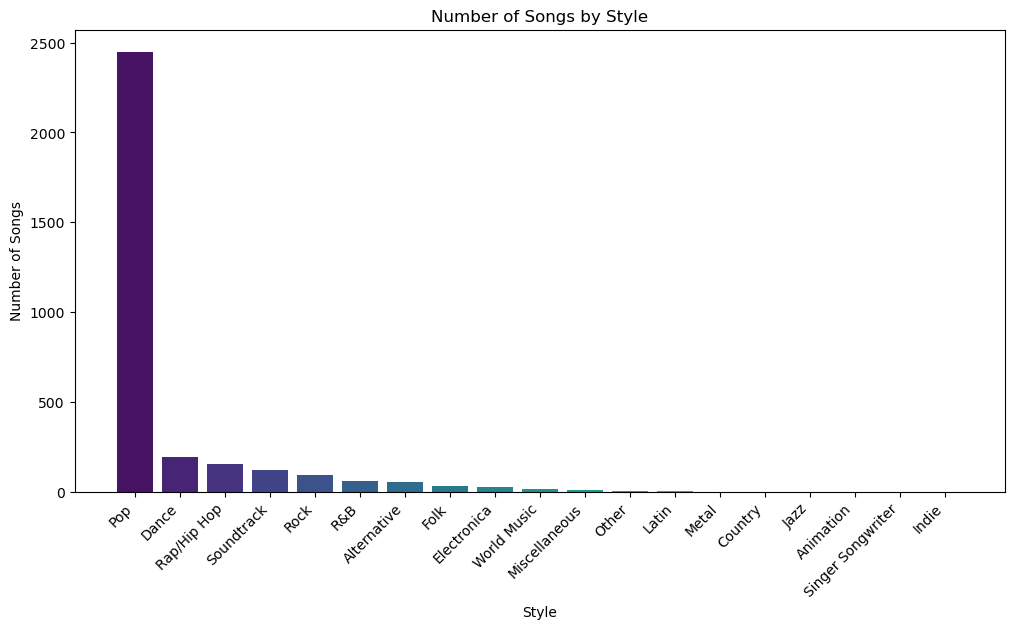

In [4]:
styles = {song["style"] for song in songs.values()}
styles = {style: [song for song in songs.values() if song["style"] == style] for style in styles if style is not None}

styles = sorted(styles.items(), key=lambda x: len(x[1]), reverse=True)

x = [style for style, songs_in_style in styles]
y = [len(songs_in_style) for style, songs_in_style in styles]

plt.figure(figsize=(12, 6))
plt.bar(x, y, color=sns.color_palette('viridis', len(styles)))
plt.xticks(rotation=45, ha="right")
plt.title("Number of Songs by Style")
plt.xlabel("Style")
plt.ylabel("Number of Songs")
plt.show()

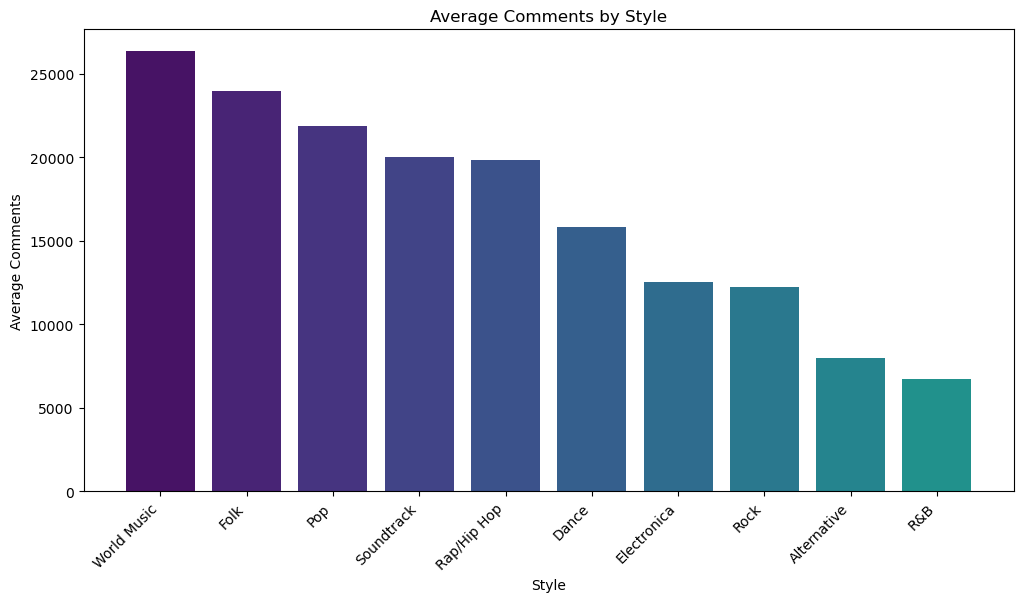

In [5]:
styles_dict = {k : v for k, v in styles if len(v) > 10}

avg_comments = []

for style, songs_in_style in styles_dict.items():
    avg_comments.append((style, np.mean([song["num_comments"] for song in songs_in_style])))
    
avg_comments = sorted(avg_comments, key=lambda x: x[1], reverse=True)

x = [style for style, avg in avg_comments]
y = [avg for style, avg in avg_comments]

plt.figure(figsize=(12, 6))
plt.bar(x, y, color=sns.color_palette('viridis', len(styles)))
plt.xticks(rotation=45, ha="right")
plt.title("Average Comments by Style")
plt.xlabel("Style")
plt.ylabel("Average Comments")
plt.show()
    

## 2. 歌曲语言分布

- 根据 `"language"` 属性划分歌曲语言
- 结论：
    - **数据集中歌曲主要为国语（2558）超半数。其次为英语（546），韩语和粤语也占据一定比例**


国语 2558
英语 546
韩语 342
粤语 302
日语 56
纯音乐 31


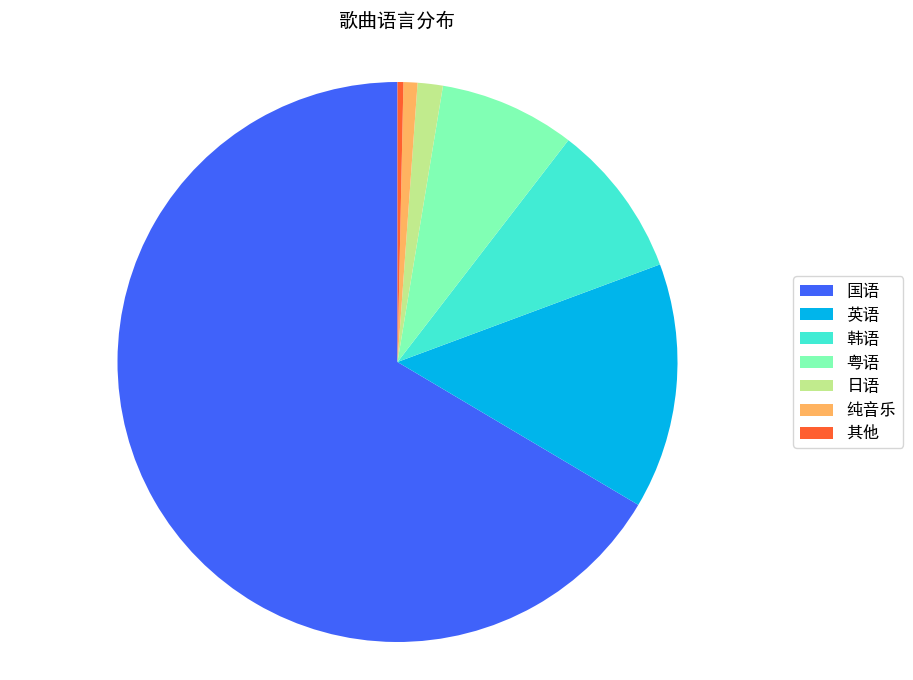

In [6]:
plt.rcParams['font.sans-serif'] = ['SimHei', 'Noto Sans SC']
plt.rcParams['axes.unicode_minus'] = False

languages = {}
for song in songs.values():
    lang = song.get('language', '未知')
    languages[lang] = languages.get(lang, 0) + 1

languages = sorted(languages.items(), key=lambda x: x[1], reverse=True)

labels = [item[0] for item in languages[:6]]
sizes = [item[1] for item in languages[:6]]
labels.append('其他')
sizes.append(sum(item[1] for item in languages[6:]))

for lan in labels:
    if lan == '其他':
        continue
    print(lan, sizes[labels.index(lan)])

plt.figure(figsize=(10, 8))

wedges, texts = plt.pie(
    sizes, 
    startangle=90, 
    colors=sns.color_palette('rainbow', len(labels)),
    textprops={'fontsize': 12}
)

plt.legend(
    wedges, 
    labels, 
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12
)

plt.title('歌曲语言分布', fontsize=14, pad=20)
plt.axis('equal')
plt.show()

## 3. 歌曲时间分布
- 根据 `"release_date"` 属性划分歌曲时间分布
- 结论：
    - **数据集中歌曲主要为2000年之后的歌曲**
    - **数据集中歌曲数量随年份而增加**

各年份歌曲发行数量 (近20年):
2005: 73首
2006: 81首
2007: 83首
2008: 95首
2009: 105首
2010: 85首
2011: 90首
2012: 97首
2013: 117首
2014: 102首
2015: 127首
2016: 152首
2017: 143首
2018: 126首
2019: 166首
2020: 187首
2021: 167首
2022: 178首
2023: 203首
2024: 256首


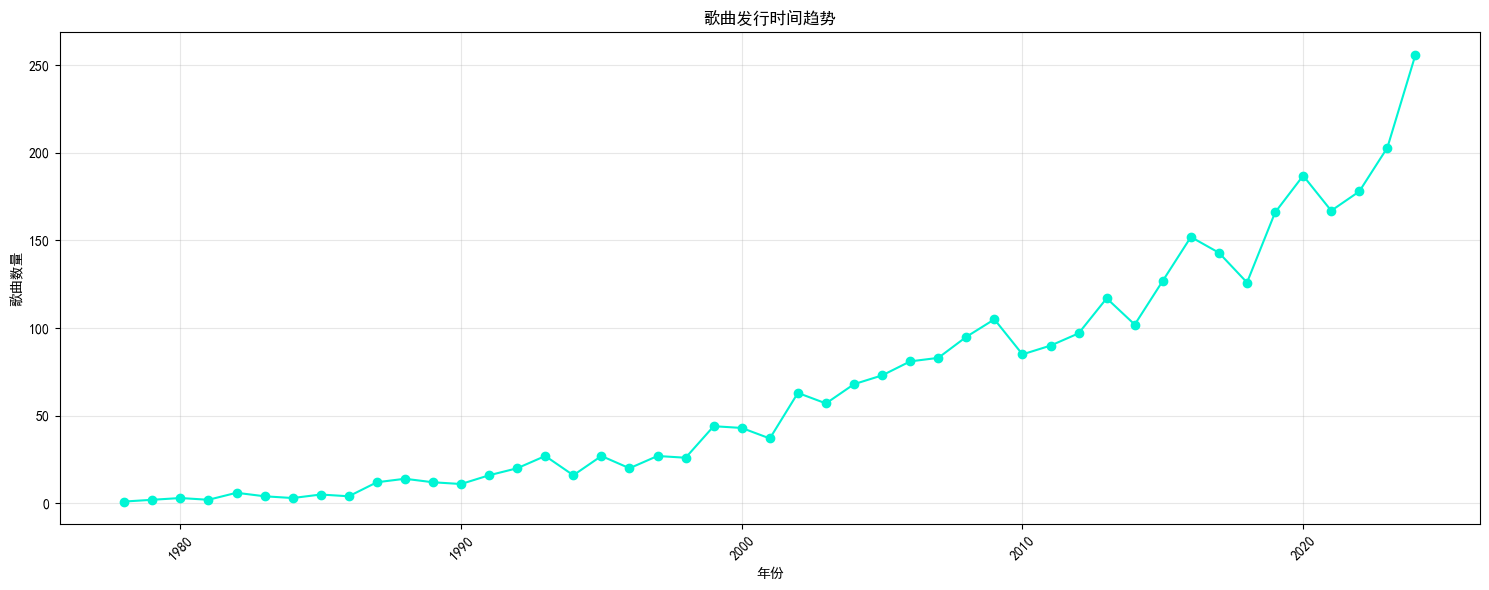

In [7]:
year_counts = {}
for song in songs.values():
    release_date = song.get('release_date')
    if release_date:
        try:
            year = int(release_date[:4])
            if 1900 <= year <= 2024:
                year_counts[year] = year_counts.get(year, 0) + 1
        except ValueError:
            pass

year_counts = sorted(year_counts.items())

print("各年份歌曲发行数量 (近20年):")
for year, count in year_counts[-20:]:
    print(f"{year}: {count}首")

plt.figure(figsize=(15, 6))
years = [item[0] for item in year_counts]
counts = [item[1] for item in year_counts]
plt.plot(years, counts, marker='o', linestyle='-', color='#00f5d4')
plt.xlabel('年份')
plt.ylabel('歌曲数量')
plt.title('歌曲发行时间趋势')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. 歌曲与歌手热度分析

- 根据 `"num_followers"` 与 `"num_comments"` 属性分析歌手与歌曲热度的相关性
- 结论：
    - **歌曲的评论数与歌手的关注度之间没有显著的相关性**
        - 即歌手热度高，不一定说明歌手的歌曲也普遍热度高
        - 歌手的歌曲都热度高，也不一定说明歌手热度高

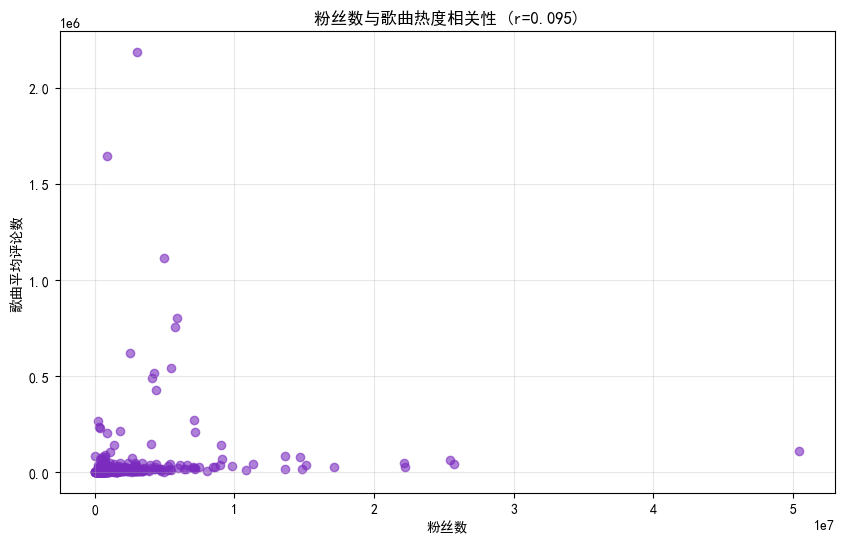

In [8]:
valid_singers = []
for singer in singers.values():
    followers = singer.get('num_followers', 0) or 0
    if followers > 0:
        song_comments = []
        for song_mid in singer.get('popular_songs', []):
            if song_mid in songs and songs[song_mid].get('num_comments'):
                song_comments.append(songs[song_mid]['num_comments'])
        if song_comments:
            valid_singers.append({
                'followers': followers,
                'avg_comments': np.mean(song_comments)
            })

followers = [s['followers'] for s in valid_singers]
avg_comments = [s['avg_comments'] for s in valid_singers]

correlation = np.corrcoef(followers, avg_comments)[0, 1]

plt.figure(figsize=(10, 6))
plt.scatter(followers, avg_comments, alpha=0.6, color='#7b2cbf')
plt.xlabel('粉丝数')
plt.ylabel('歌曲平均评论数')
plt.title(f'粉丝数与歌曲热度相关性 (r={correlation:.3f})')
plt.grid(True, alpha=0.3)
plt.show()

## 5. 歌手产出分析

- 根据 `"num_songs"` `num_albums` `"num_movies"` `"num_followers"` 属性分析歌手产出与热度情况
- 结论：
    - **歌手的歌曲数量与专辑数量之间存在显著正相关性**
        - 解释为歌手通常会发行专辑，而专辑中包含多首歌曲。所以歌手发的专辑越多，其歌曲数量也越多
    - **歌手的关注数量与MV数量之间存在显著正相关性**
        - 可解释为歌手关注数量越多，其制作的MV数量也越多
    - **另外四组关系中不存在显著的相关性**

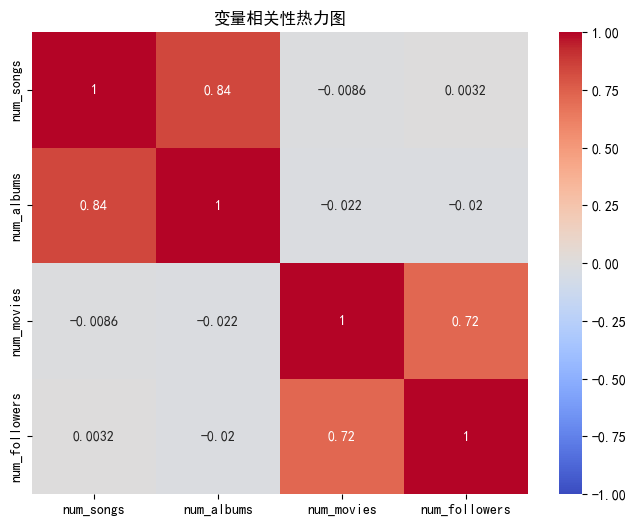

In [9]:
num_songs = [singer.get('num_songs', 0) or 0 for singer in singers.values()]
num_albums = [singer.get('num_albums', 0) or 0 for singer in singers.values()]
num_movies = [singer.get('num_movies', 0) or 0 for singer in singers.values()]
num_followers = [singer.get('num_followers', 0) or 0 for singer in singers.values()]

data = pd.DataFrame({
    'num_songs': num_songs,
    'num_albums': num_albums,
    'num_movies': num_movies,
    'num_followers': num_followers
})

corr_matrix = data.corr()

plt.rcParams['font.sans-serif'] = ['SimHei']

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('变量相关性热力图')
plt.show()

## 歌手的歌曲数量与专辑数量之间存在显著正相关性

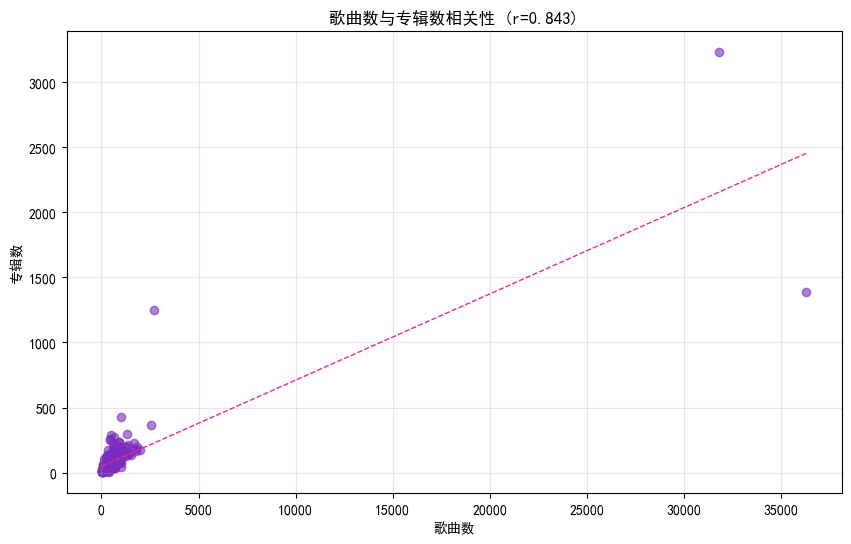

In [15]:
songs_album_correlation = np.corrcoef(num_songs, num_albums)[0, 1]

z = np.polyfit(num_songs, num_albums, 1)
p = np.poly1d(z)

x_line = np.linspace(min(num_songs), max(num_songs), 1000)
y_line = p(x_line)

plt.figure(figsize=(10, 6))
plt.scatter(num_songs, num_albums, alpha=0.6, color='#7b2cbf')
plt.plot(x_line, y_line, color='#f72585', linewidth=1, linestyle='--')
plt.xlabel('歌曲数')
plt.ylabel('专辑数')
plt.title(f'歌曲数与专辑数相关性 (r={songs_album_correlation:.3f})')
plt.grid(True, alpha=0.3)
plt.show()

- 放大进入左下角密集区域详细查看

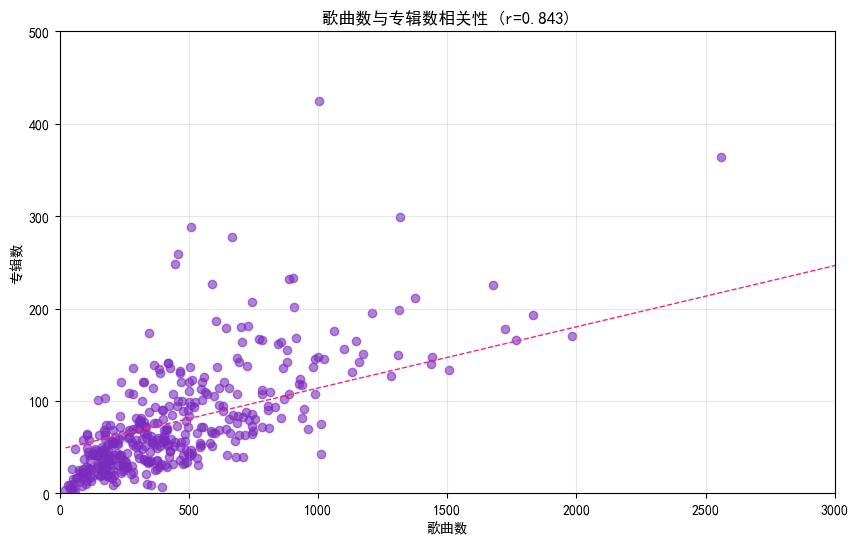

In [18]:
songs_album_correlation = np.corrcoef(num_songs, num_albums)[0, 1]

z = np.polyfit(num_songs, num_albums, 1)
p = np.poly1d(z)

x_line = np.linspace(min(num_songs), max(num_songs), 1000)
y_line = p(x_line)

plt.figure(figsize=(10, 6))
plt.scatter(num_songs, num_albums, alpha=0.6, color='#7b2cbf')
plt.plot(x_line, y_line, color='#f72585', linewidth=1, linestyle='--')
plt.xlabel('歌曲数')
plt.ylabel('专辑数')
plt.title(f'歌曲数与专辑数相关性 (r={songs_album_correlation:.3f})')
plt.grid(True, alpha=0.3)
plt.xlim(0, 3000)
plt.ylim(0, 500)
plt.show()

## 歌手的关注数量与MV数量之间存在显著正相关性

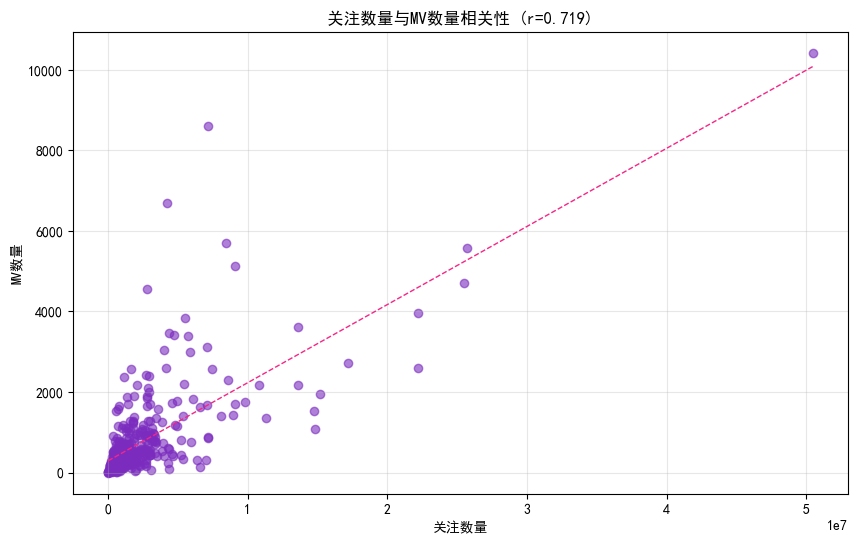

In [19]:
followers_movies_correlation = np.corrcoef(num_followers, num_movies)[0, 1]

z = np.polyfit(num_followers, num_movies, 1)
p = np.poly1d(z)

x_line = np.linspace(min(num_followers), max(num_followers), 1000)
y_line = p(x_line)

plt.figure(figsize=(10, 6))
plt.scatter(num_followers, num_movies, alpha=0.6, color='#7b2cbf')
plt.plot(x_line, y_line, color='#f72585', linewidth=1, linestyle='--')
plt.xlabel('关注数量')
plt.ylabel('MV数量')
plt.title(f'关注数量与MV数量相关性 (r={followers_movies_correlation:.3f})')
plt.grid(True, alpha=0.3)
plt.show()

- 放大进入左下角密集区域详细查看

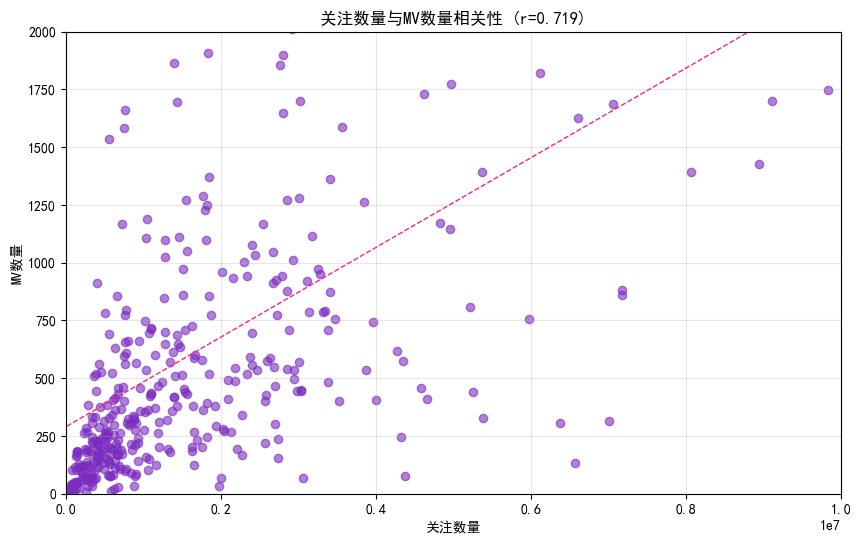

In [21]:
followers_movies_correlation = np.corrcoef(num_followers, num_movies)[0, 1]

z = np.polyfit(num_followers, num_movies, 1)
p = np.poly1d(z)

x_line = np.linspace(min(num_followers), max(num_followers), 1000)
y_line = p(x_line)

plt.figure(figsize=(10, 6))
plt.scatter(num_followers, num_movies, alpha=0.6, color='#7b2cbf')
plt.plot(x_line, y_line, color='#f72585', linewidth=1, linestyle='--')
plt.xlabel('关注数量')
plt.ylabel('MV数量')
plt.title(f'关注数量与MV数量相关性 (r={followers_movies_correlation:.3f})')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1e7)
plt.ylim(0, 2000)
plt.show()